In [ ]:
# env is norm_scRNAseq

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt

In [2]:
# Set global seeds
np.random.seed(42)
random.seed(42)

In [3]:
sc.settings.set_figure_params(figsize=(10, 10), facecolor="white")

In [ ]:
adata = sc.read_h5ad(
    "../adata/IBD.h5ad"
)
adata

AnnData object with n_obs × n_vars = 174015 × 38606
    obs: 'sample', 'GC_Sample_Number', 'Gender', 'Date_of_surgery', 'Location', 'Disease', 'Segment', 'Age', 'Cells_prefix', 'Condition', 'Disease_segment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'outlier_colors', 'mt_outlier', 'mt_outlier_colors', 'leiden', 'cell_type_broad', 'scDblFinder_score', 'scDblFinder_class', 'leiden_0.5', 'leiden_2.0', 'leiden_5.0', 'celltypist_predicted_labels', 'celltypist_over_clustering', 'celltypist_majority_voting', 'celltypist_conf_score', 'cell_type_fine'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_names', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersec

In [ ]:
# sanity check
display("Max in adata.X:", adata.X.max())
display("Max in layer counts:", adata.layers["counts"].max())
display("Max in layer soupx counts:", adata.layers["soupX_counts"].max())

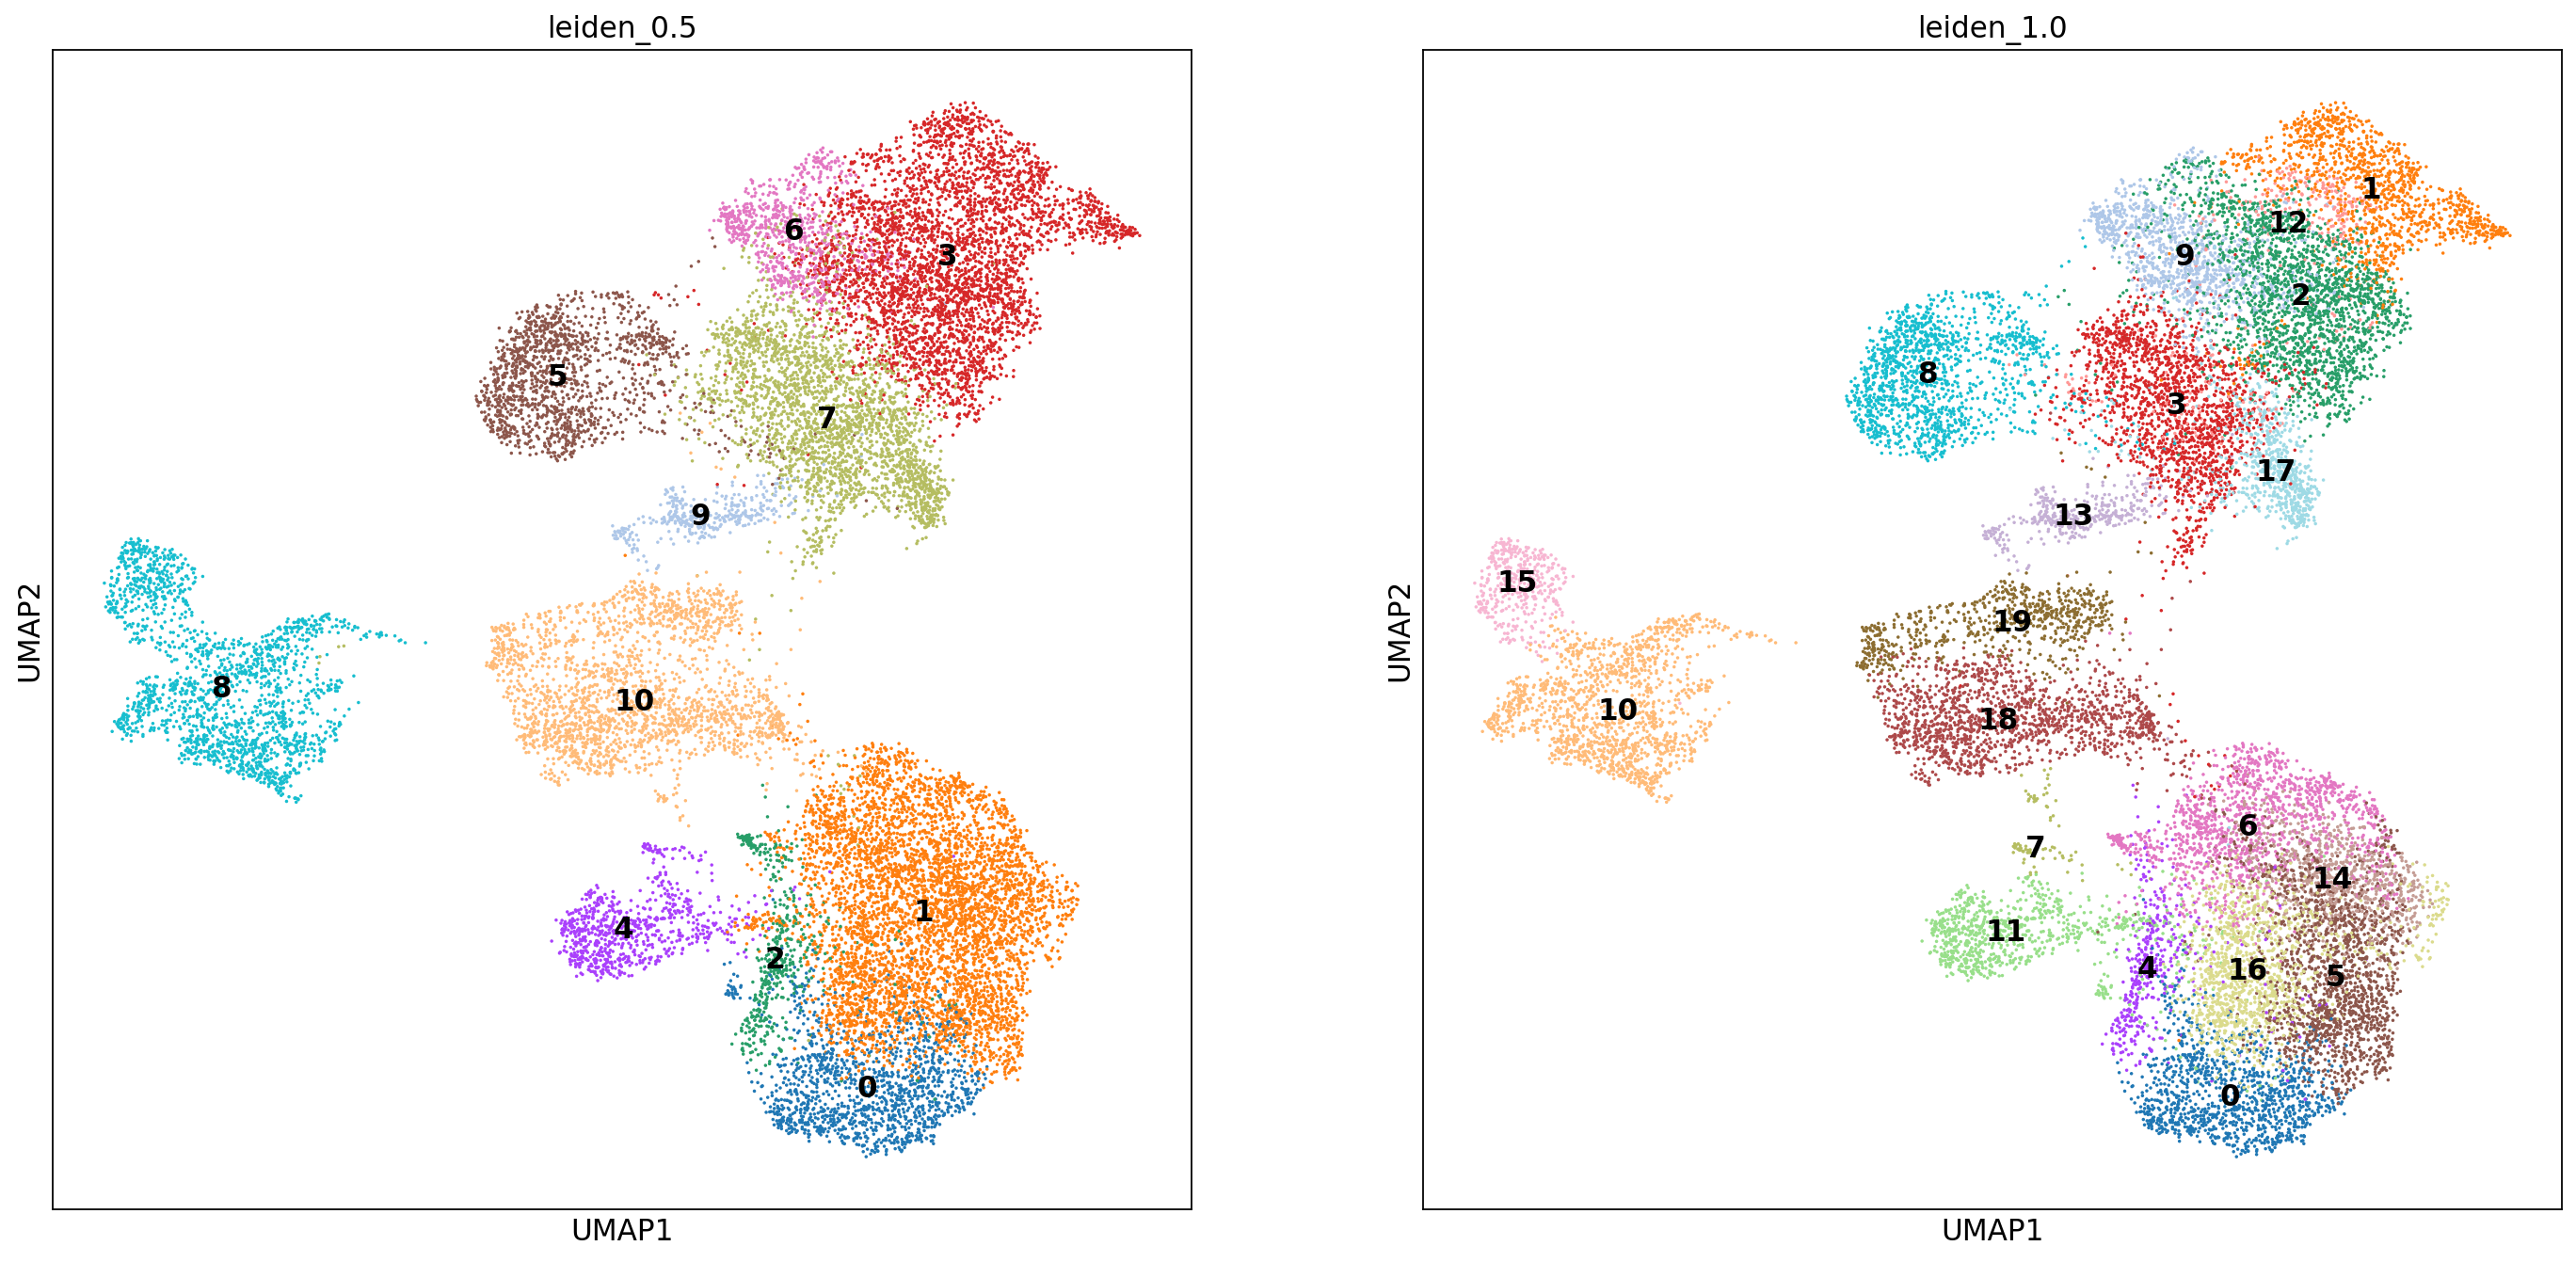

In [6]:
# subset mesenchymal

adata_sub = adata[
    adata.obs['leiden_0.5'].isin(["8", "20", "9", "19"])
].copy()

adata_sub.X = adata_sub.layers["soupX_counts"].copy()
sc.pp.normalize_total(adata_sub)
sc.pp.log1p(adata_sub)
sc.pp.highly_variable_genes(adata_sub, n_top_genes=2000, batch_key="sample")
sc.tl.pca(adata_sub, svd_solver='arpack')
sc.pp.neighbors(adata_sub, random_state=42)
sc.tl.umap(adata_sub, random_state=42)
sc.tl.leiden(adata_sub, resolution=0.5, key_added="leiden_0.5", flavor="igraph", n_iterations=-1, random_state=42)
sc.tl.leiden(adata_sub, resolution=1.0, key_added="leiden_1.0", flavor="igraph", n_iterations=-1, random_state=42)
sc.pl.umap(adata_sub, color = ['leiden_0.5', 'leiden_1.0'], legend_loc = 'on data', size = 10)

In [8]:
marker_genes = {
    "Pericytes contractile" : ["MYH11", "ADIRF", "RERGL", "NTRK2"],
    "Pericytes": ["RGS5", "STEAP4", "NOTCH3"],
    "Smooth muscle cells" : ["ACTG2", "HHIP", "MYOCD"],
    "Fibroblasts (ADAMDEC1)": ["ADAMDEC1", "CCL13", "CCL11", "CCL8"],
    "Myofibroblasts": ["F3", "EDNRB", "ALKAL2", "SOX6", "NPY", "ACTA2"],
    "Fibroblasts (FAP proliferating)": ["TOP2A", "CENPF", "MKI67"],
    "Fibroblasts (FAP)": ["MMP1", "MMP3", "CHI3L1", "IL11", "FAP", "CD82", "TWIST1", "POSTN"],
    "Fibroblasts (ABL2)": ["CXCL8", "CXCL2", "ABL2", "IL6", "CLDN1", "PLIN2"],
    "Fibroblasts (CD34+ GREM1-)": ["MFAP5", "IGFBP6", "CD55", "SFRP2", "CD34", "C3"],
    "Fibroblasts (CD34+ GREM1+)": ["MGP", "GREM1", "C7"],
    "Mural": ["MYH11", "RGS5", "PDGFRB", "PDGFRA"],
    "new SMC":["TAGLN","ACTA2","TPM2"]
}

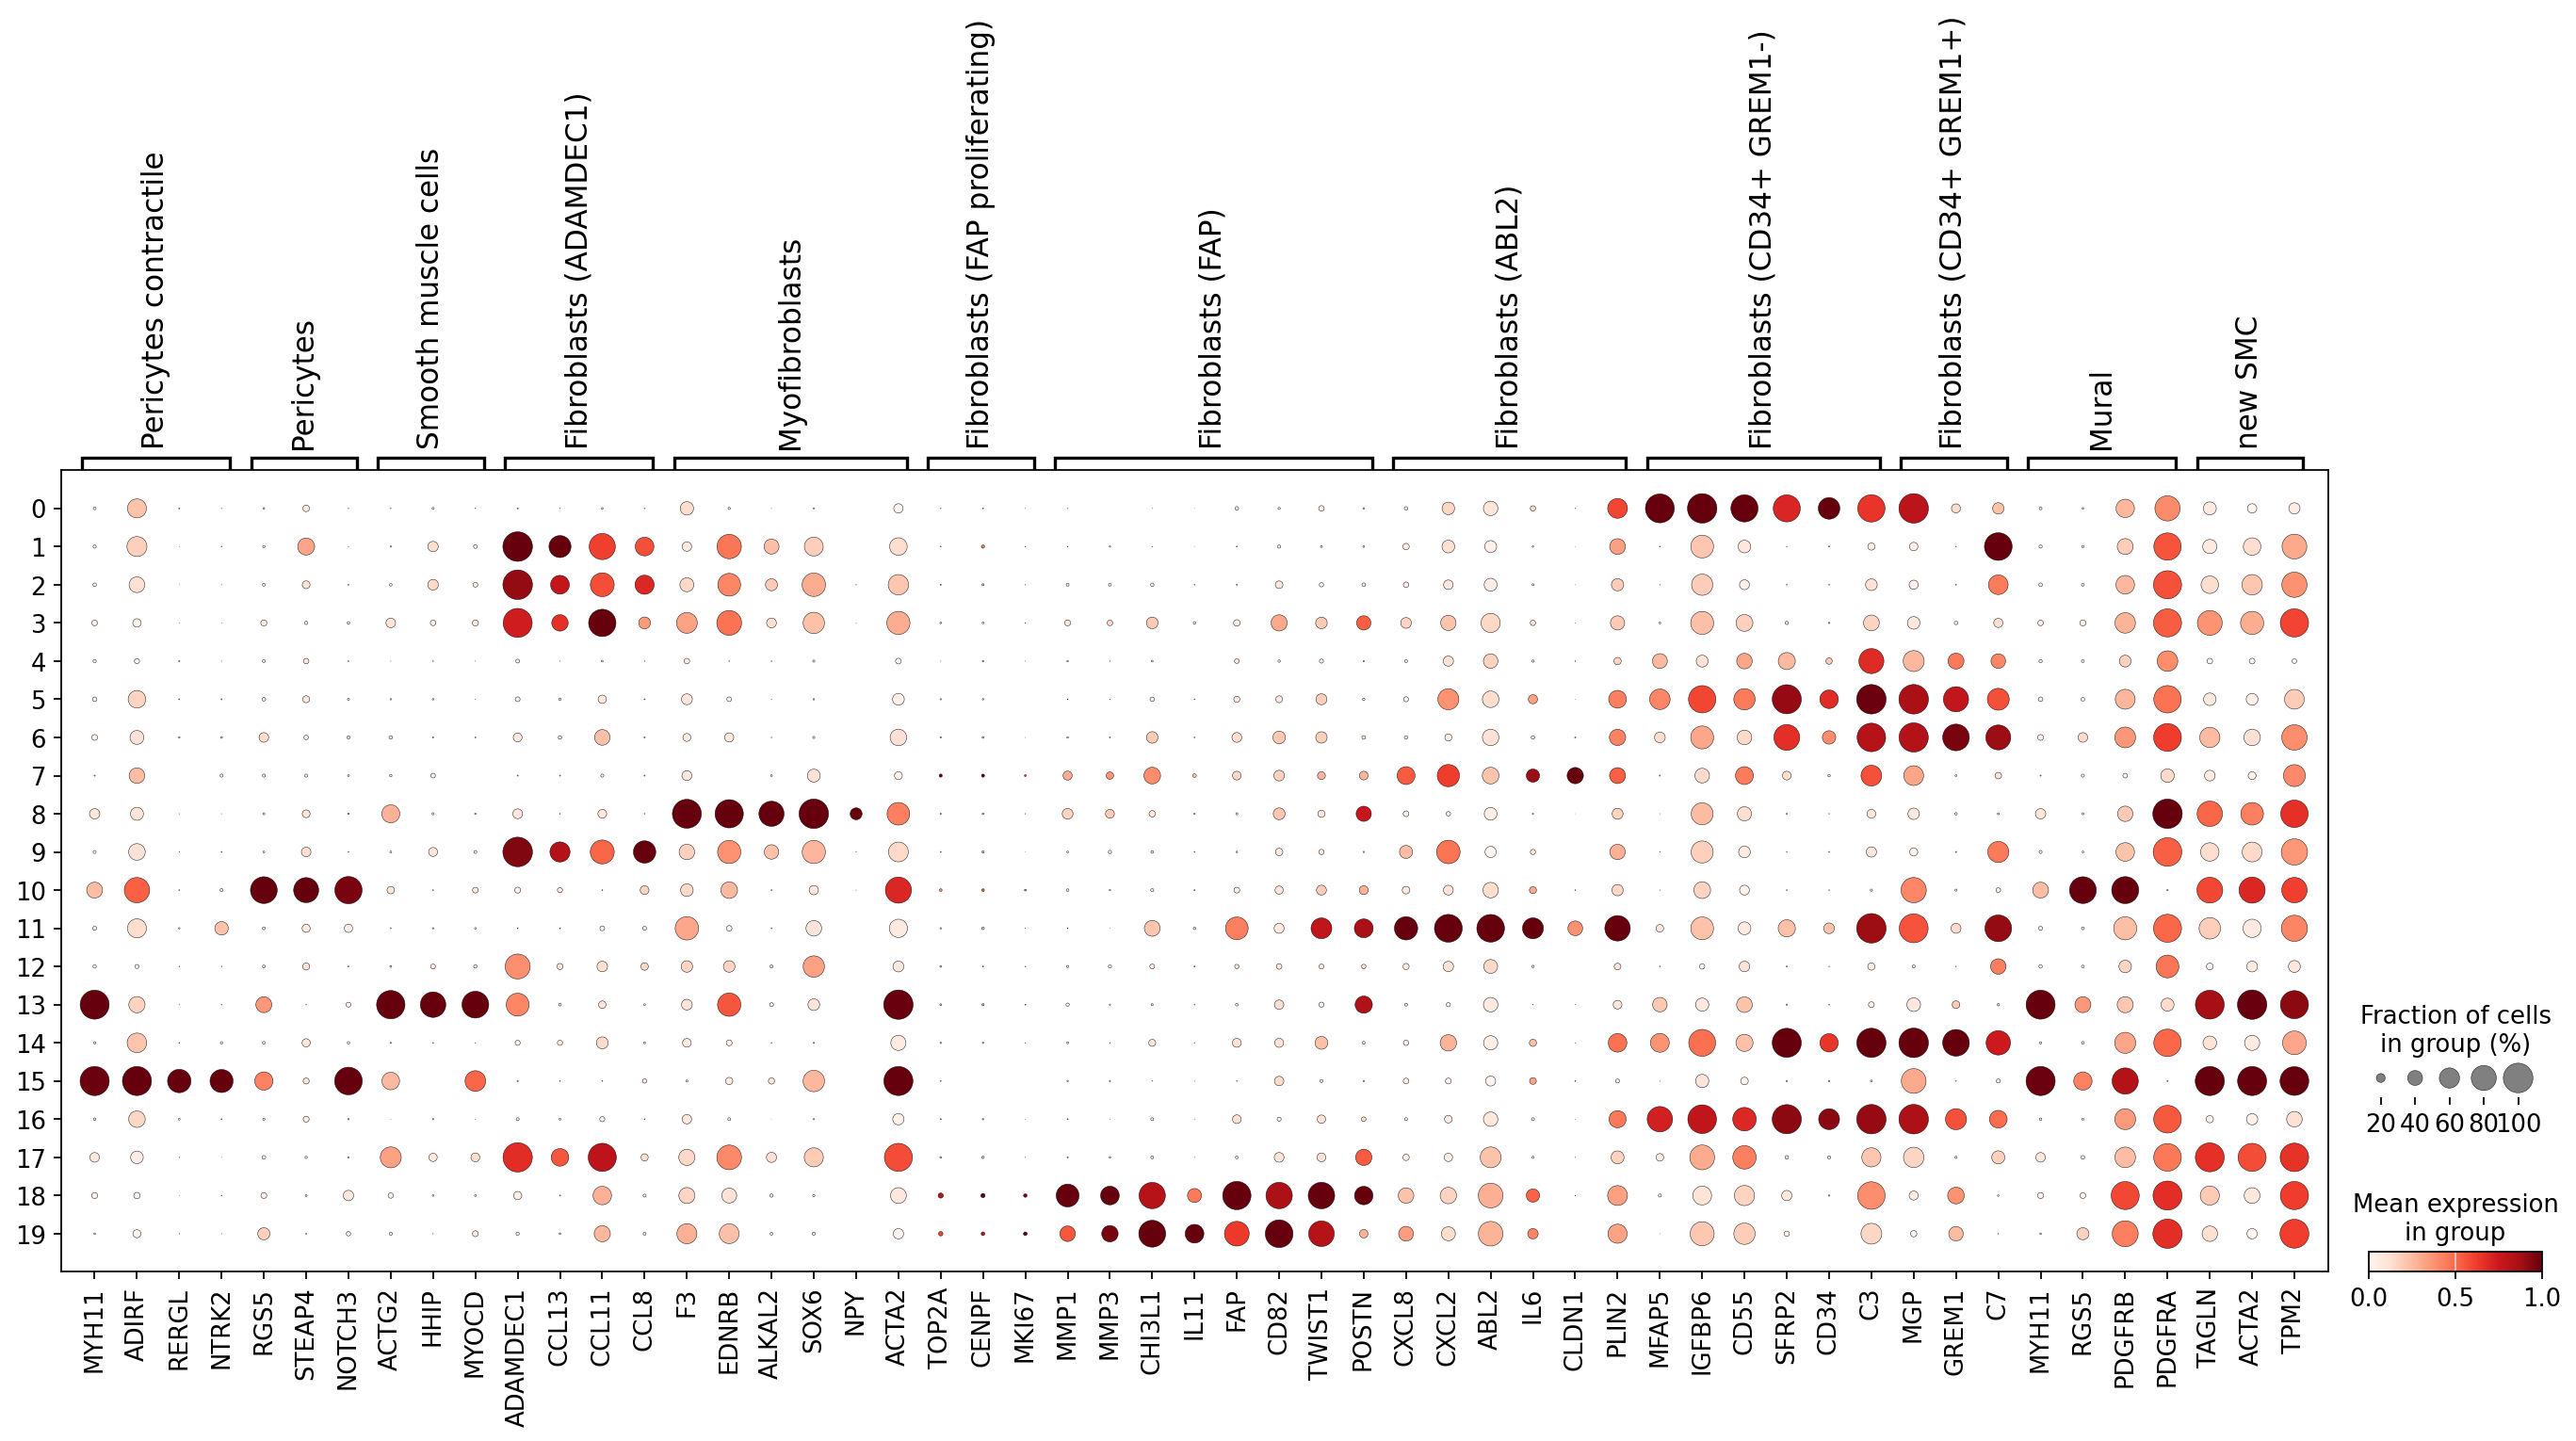

In [9]:
sc.pl.dotplot(adata_sub, marker_genes, groupby="leiden_1.0", standard_scale="var")

In [10]:
adata_sub.obs["cell_type_mesenchymal"] = adata_sub.obs["leiden_1.0"].map(
    {
        "0": "Fibroblasts (CD34+ GREM1-)",
        "1": "Fibroblasts (ADAMDEC1)",
        "2": "Fibroblasts (ADAMDEC1)",
        "3": "Fibroblasts (ADAMDEC1)",
        "4": "Fibroblasts (CD34+ GREM1-)",
        "5": "Fibroblasts (CD34+ GREM1+)",
        "6": "Fibroblasts (CD34+ GREM1+)",
        "7": "Fibroblasts (ABL2)",
        "8": "Myofibroblasts",
        "9": "Fibroblasts (ADAMDEC1)",
        "10": "Pericytes",
        "11": "Fibroblasts (ABL2)",
        "12": "Fibroblasts (ADAMDEC1)",
        "13": "Smooth muscle cells",
        "14": "Fibroblasts (CD34+ GREM1+)",
        "15": "Pericytes contractile",
        "16": "Fibroblasts (CD34+ GREM1-)",
        "17": "Fibroblasts (ADAMDEC1)",
        "18": "Fibroblasts (FAP)",
        "19": "Fibroblasts (FAP)"
    }
)

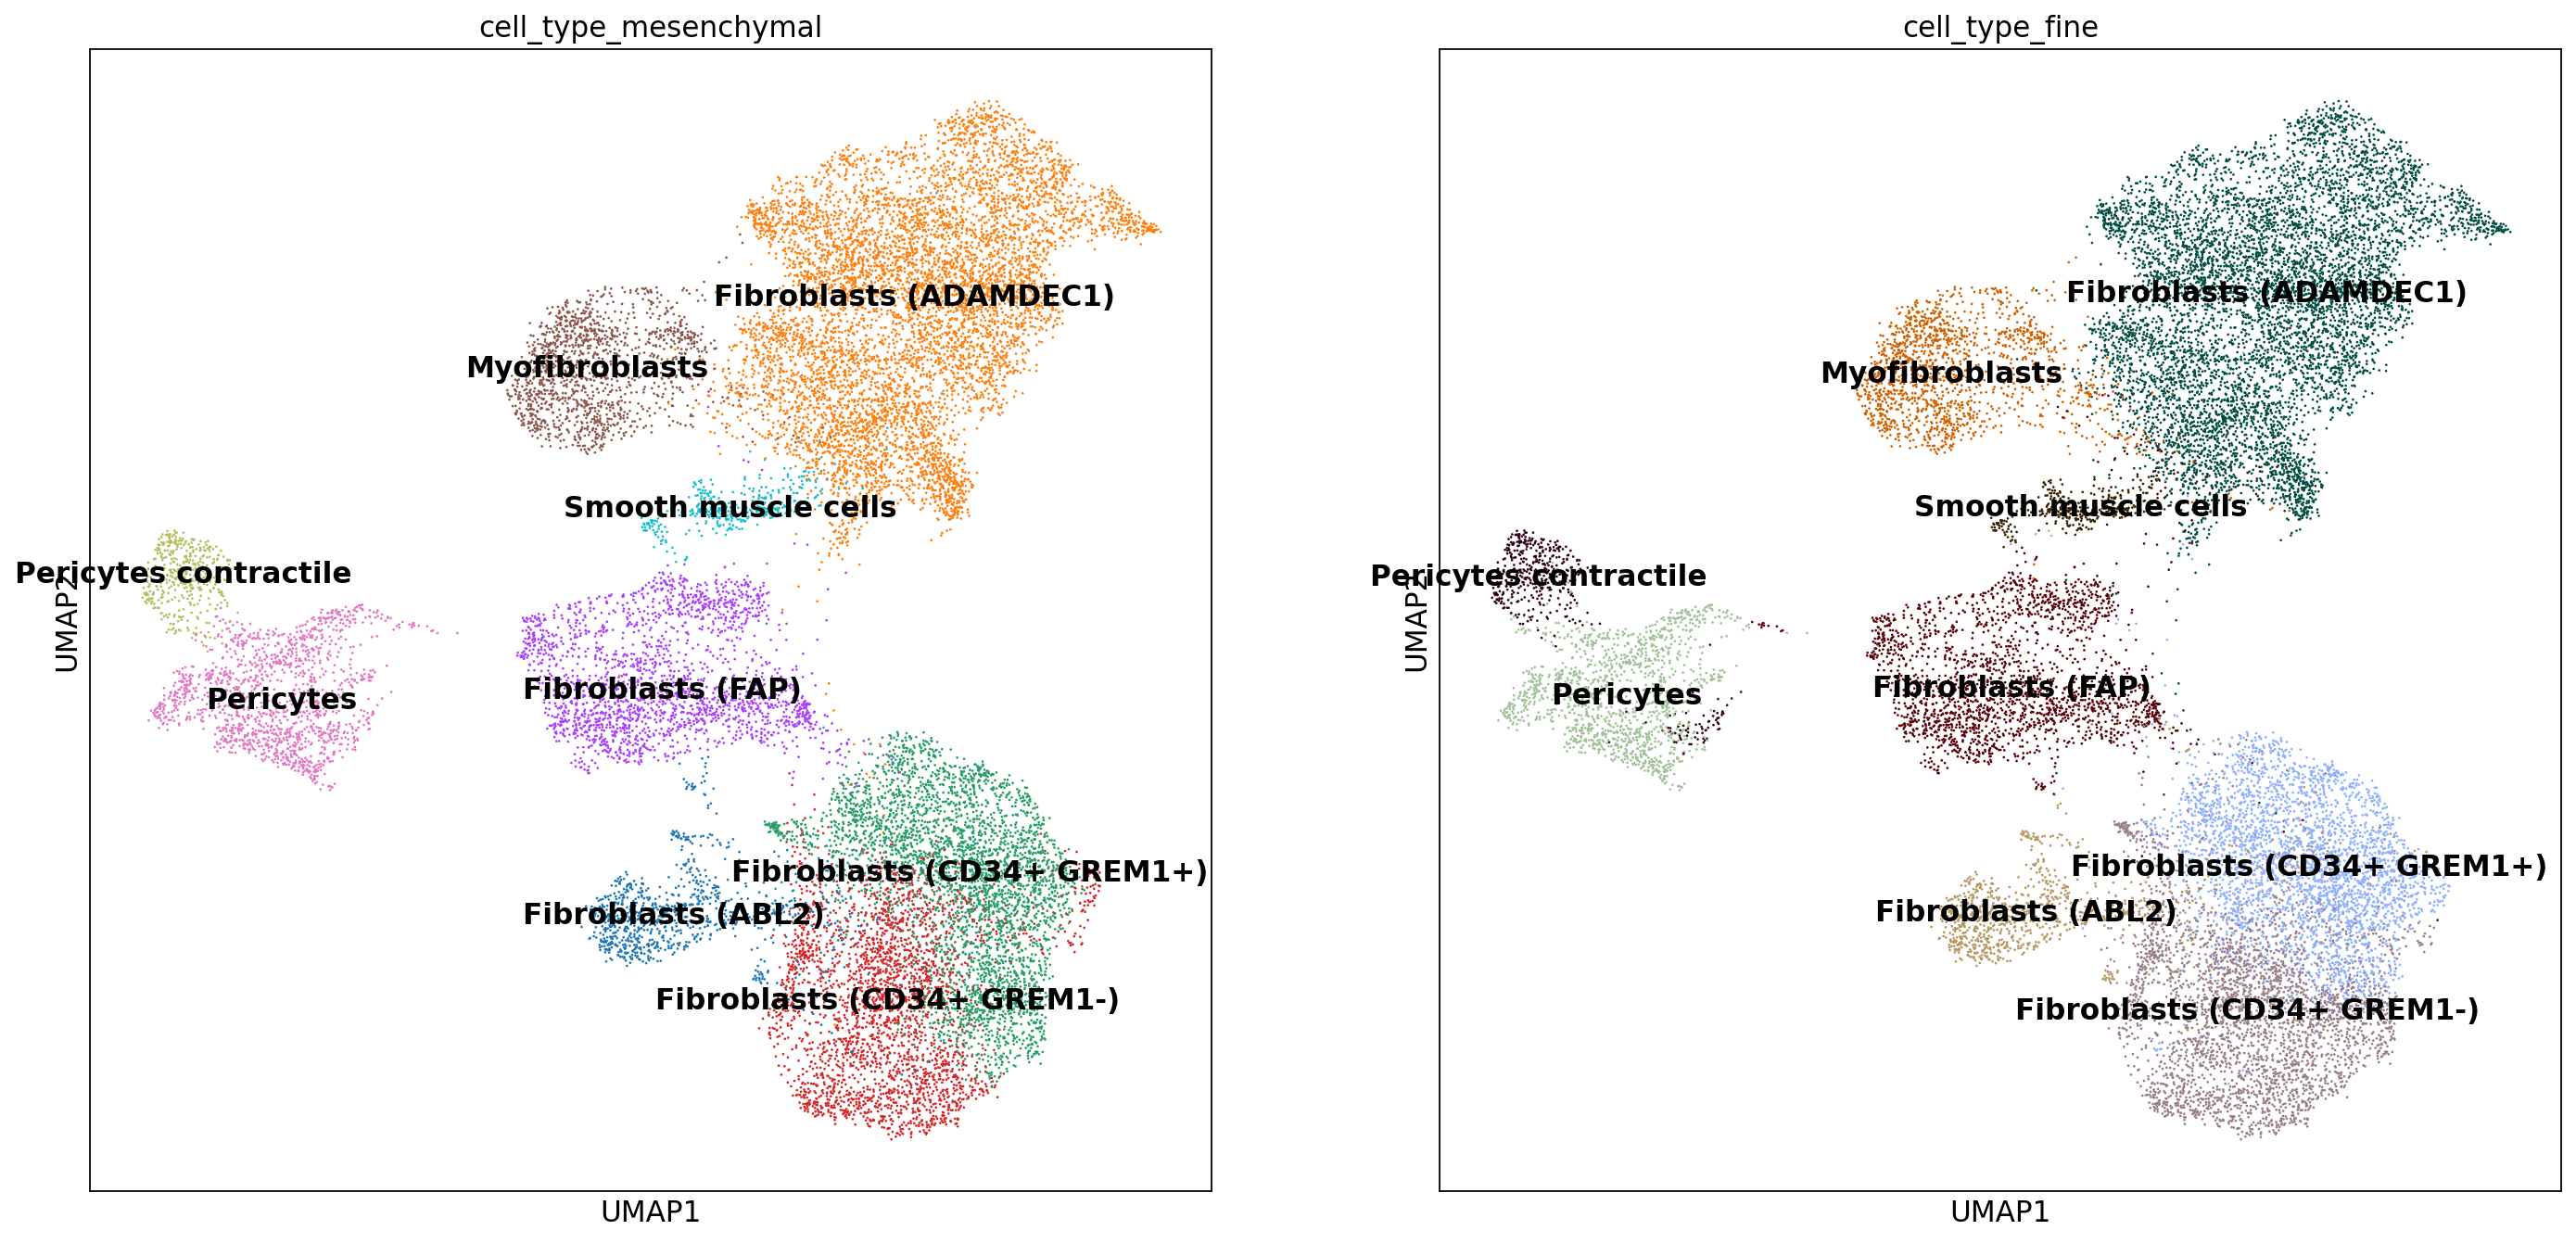

In [11]:
sc.pl.umap(adata_sub, color = ['cell_type_mesenchymal', 'cell_type_fine'], legend_loc = 'on data')

In [12]:
# make sure both adatas have cells indexed by cell names
assert all(adata_sub.obs_names.isin(adata.obs_names))
# assert throws an error if False, nothing happens if True

In [13]:
# update values only for the overlapping cells
# make sure target column is string
adata.obs["cell_type_fine"] = adata.obs["cell_type_fine"].astype(str)

# update only overlapping cells
adata.obs.loc[adata_sub.obs_names, "cell_type_fine"] = adata_sub.obs["cell_type_mesenchymal"].astype(str).values

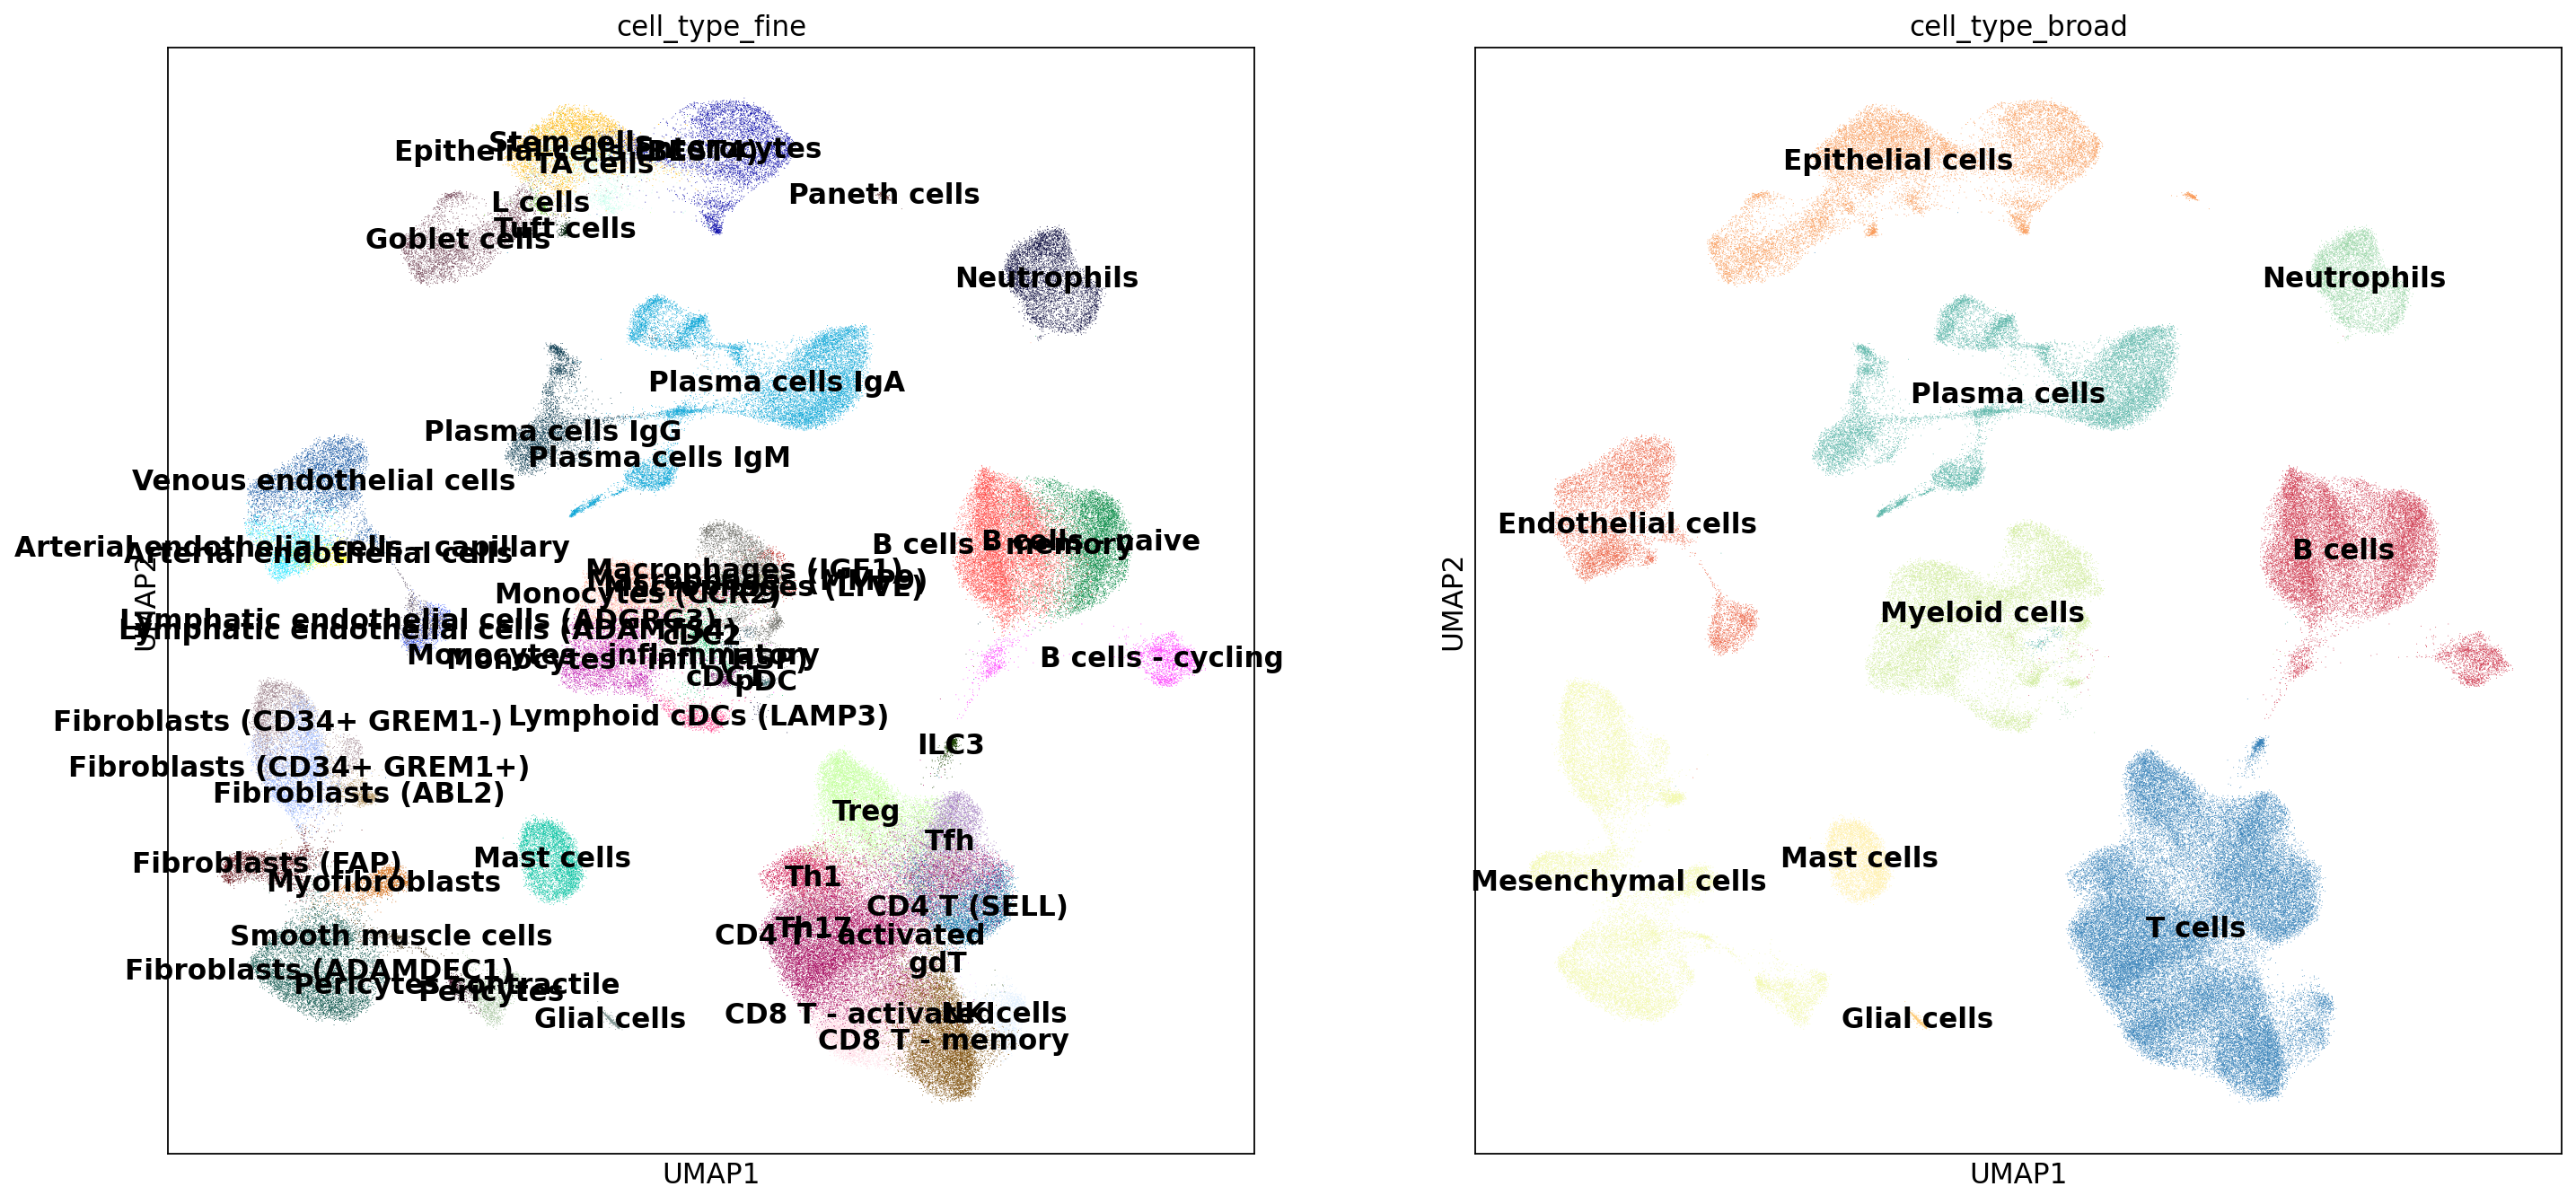

In [14]:
sc.pl.umap(adata, color = ['cell_type_fine', 'cell_type_broad'], legend_loc = 'on data')

In [ ]:
adata.write("../adata/IBD.h5ad")

In [ ]:
adata_sub.write("../adata/IBD_mesenchymal.h5ad")